In [1]:
# Step 1 - Install Dependencies

!pip install -q matplotlib seaborn pandas numpy

print("All dependencies installed successfully")

All dependencies installed successfully


In [2]:
# Step 2 - Mount Drive and Set Paths

from google.colab import drive
import os

drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/Depixen/PROJECT_2_TEXT_TO_KG'

metrics_paths = {
    'Phi-3.5 Mini + LoRA'   : base_path + '/phi35_lora/results/metrics.csv',
    'Gemma 2 2B IT + QLoRA' : base_path + '/Gemma2_2B_IT_QLoRA/results/metrics.csv',
}

pred_paths = {
    'Phi-3.5 Mini + LoRA'   : base_path + '/phi35_lora/results/predictions.csv',
    'Gemma 2 2B IT + QLoRA' : base_path + '/Gemma2_2B_IT_QLoRA/results/predictions_with_metrics.csv',
}

output_path = base_path + '/comparison'
os.makedirs(output_path, exist_ok=True)

print("Drive mounted successfully")
print("Output path:", output_path)

Mounted at /content/drive
Drive mounted successfully
Output path: /content/drive/MyDrive/Depixen/PROJECT_2_TEXT_TO_KG/comparison


In [3]:
# Step 3 - Load Metrics from Both Models

import pandas as pd

df_phi35  = pd.read_csv(metrics_paths['Phi-3.5 Mini + LoRA'])
df_gemma2 = pd.read_csv(metrics_paths['Gemma 2 2B IT + QLoRA'])

print("Phi-3.5 LoRA metrics:")
print(df_phi35.to_string())
print("\nGemma 2 QLoRA metrics:")
print(df_gemma2.to_string())

def extract_metrics(df):
    row = df.iloc[0]
    return {
        'f1'               : float(row.get('f1_score', row.get('f1', 0))),
        'recall'           : float(row.get('recall', 0)),
        'precision'        : float(row.get('precision', 0)),
        'rouge_l'          : float(row.get('rouge-l', row.get('rouge_l', 0))),
        'bert_score'       : float(row.get('bertscore', row.get('bert_score', 0))),
        'hallucination_l1' : float(row.get('hallucination_l1', 0)),
        'hallucination_l2' : float(row.get('hallucination_l2', 0)),
    }

metrics = {
    'Phi-3.5 Mini + LoRA'   : extract_metrics(df_phi35),
    'Gemma 2 2B IT + QLoRA' : extract_metrics(df_gemma2),
}

print("\nMetrics loaded successfully")

Phi-3.5 LoRA metrics:
                   model method  lora_rank  lora_alpha  epochs  learning_rate  train_samples  test_samples  f1_score  recall  precision  rouge-l  bertscore  hallucination_l1  hallucination_l2  training_loss  training_time
0  Phi-3.5 Mini Instruct   LoRA         16          32       3         0.0002           6470          1387    0.9954   0.995     0.9959   0.9991     0.9998               0.0               0.0         0.3008          26.01

Gemma 2 QLoRA metrics:
           model method      f1  recall  precision  rouge_l  bert_score  hallucination_l1  hallucination_l2
0  Gemma 2 2B IT  QLoRA  0.9756  0.9688     0.9835   0.9783      0.9975            0.0036            0.1233

Metrics loaded successfully


In [4]:
# Step 4 - Comparison Table

import pandas as pd

metric_labels = {
    'f1'               : 'F1 Score',
    'recall'           : 'Recall',
    'precision'        : 'Precision',
    'rouge_l'          : 'ROUGE-L',
    'bert_score'       : 'BERTScore',
    'hallucination_l1' : 'Hallucination L1',
    'hallucination_l2' : 'Hallucination L2',
}

rows = []
for key, label in metric_labels.items():
    v1     = metrics['Phi-3.5 Mini + LoRA'][key]
    v2     = metrics['Gemma 2 2B IT + QLoRA'][key]
    lower  = key in ['hallucination_l1', 'hallucination_l2']
    winner = 'Phi-3.5 + LoRA' if (v1 <= v2 if lower else v1 >= v2) else 'Gemma 2 + QLoRA'
    rows.append({
        'Metric'                : label,
        'Phi-3.5 Mini + LoRA'   : v1,
        'Gemma 2 2B IT + QLoRA' : v2,
        'Difference'            : round(v1 - v2, 4),
        'Winner'                : winner,
    })

df_comparison = pd.DataFrame(rows)

print("Model Comparison Table")
print("=" * 85)
print(df_comparison.to_string(index=False))
print("=" * 85)

df_comparison.to_csv(output_path + '/comparison_table.csv', index=False)
print("\nComparison table saved to Drive")

Model Comparison Table
          Metric  Phi-3.5 Mini + LoRA  Gemma 2 2B IT + QLoRA  Difference         Winner
        F1 Score               0.9954                 0.9756      0.0198 Phi-3.5 + LoRA
          Recall               0.9950                 0.9688      0.0262 Phi-3.5 + LoRA
       Precision               0.9959                 0.9835      0.0124 Phi-3.5 + LoRA
         ROUGE-L               0.9991                 0.9783      0.0208 Phi-3.5 + LoRA
       BERTScore               0.9998                 0.9975      0.0023 Phi-3.5 + LoRA
Hallucination L1               0.0000                 0.0036     -0.0036 Phi-3.5 + LoRA
Hallucination L2               0.0000                 0.1233     -0.1233 Phi-3.5 + LoRA

Comparison table saved to Drive


In [6]:
import numpy as np

# Normalize keys for both models
def normalize_metrics(raw):
    return {
        "f1"               : float(raw.get('f1_score', raw.get('f1', 0))),
        "recall"           : float(raw.get('recall', 0)),
        "precision"        : float(raw.get('precision', 0)),
        "rouge_l"          : float(raw.get('rouge-l', raw.get('rouge_l', 0))),
        "bert_score"       : float(raw.get('bertscore', raw.get('bert_score', 0))),
        "hallucination_l1" : float(raw.get('hallucination_l1', 0)),
        "hallucination_l2" : float(raw.get('hallucination_l2', 0)),
    }

normalized = {name: normalize_metrics(raw) for name, raw in metrics.items()}

# Define weights
weights = {
    "f1"               :  0.30,
    "recall"           :  0.20,
    "precision"        :  0.15,
    "rouge_l"          :  0.10,
    "bert_score"       :  0.10,
    "hallucination_l1" : -0.10,
    "hallucination_l2" : -0.05,
}

print("=" * 60)
print("BEST MODEL SELECTION - WEIGHTED SCORING")
print("=" * 60)

print("\nMetric Weights:")
print("-" * 40)
for metric, weight in weights.items():
    direction = "higher is better" if weight > 0 else "lower is better"
    print(f"  {metric:<20} weight: {weight:+.2f}  ({direction})")

# Compute weighted scores
scores = {}
print("\nWeighted Scores per Model:")
print("-" * 40)

for model_name, metrics_data in normalized.items():
    total_score = 0
    print(f"\n{model_name}")
    for metric, weight in weights.items():
        value        = metrics_data[metric]
        contribution = weight * value
        total_score += contribution
        print(f"  {metric:<20} value: {value:.4f}  weight: {weight:+.2f}  contribution: {contribution:+.4f}")
    scores[model_name] = total_score
    print(f"  {'TOTAL SCORE':<20} {total_score:.4f}")

# Determine best model
best_model  = max(scores, key=scores.get)
other_model = [m for m in scores if m != best_model][0]
score_diff  = scores[best_model] - scores[other_model]

best_m  = normalized[best_model]
other_m = normalized[other_model]

print("\n" + "=" * 60)
print("FINAL VERDICT")
print("=" * 60)

for model_name, score in scores.items():
    marker = " <-- BEST MODEL" if model_name == best_model else ""
    print(f"  {model_name:<30} score: {score:.4f}{marker}")

print(f"\nScore difference     : {score_diff:.4f}")
print(f"Best model selected  : {best_model}")

print("\nMetric Comparison:")
print("-" * 40)
print(f"  {'Metric':<20} {list(normalized.keys())[0]:<25} {list(normalized.keys())[1]:<25}")
print(f"  {'-'*68}")
for metric in weights.keys():
    v1 = normalized[list(normalized.keys())[0]][metric]
    v2 = normalized[list(normalized.keys())[1]][metric]
    print(f"  {metric:<20} {v1:<25} {v2:<25}")

print("\nKey factors in selection:")
if best_m['hallucination_l1'] < other_m['hallucination_l1']:
    print("  - Lower hallucination L1 - critical for KG reliability")
if best_m['hallucination_l2'] < other_m['hallucination_l2']:
    print("  - Lower hallucination L2 - all entities grounded in input")
if best_m['f1'] > other_m['f1']:
    print("  - Higher F1 score - better overall extraction quality")
if best_m['recall'] > other_m['recall']:
    print("  - Higher recall - fewer missing triples")
if best_m['rouge_l'] > other_m['rouge_l']:
    print("  - Higher ROUGE-L - better format compliance")

print("\nEfficiency note:")
print(f"  Gemma 2 QLoRA uses ~2.3 GB vs ~7.64 GB for Phi-3.5 LoRA")
print(f"  If memory is constrained Gemma 2 QLoRA is the practical choice")

print("\n" + "=" * 60)
print(f"RECOMMENDED FOR DEPLOYMENT: {best_model}")
print("=" * 60)

BEST MODEL SELECTION - WEIGHTED SCORING

Metric Weights:
----------------------------------------
  f1                   weight: +0.30  (higher is better)
  recall               weight: +0.20  (higher is better)
  precision            weight: +0.15  (higher is better)
  rouge_l              weight: +0.10  (higher is better)
  bert_score           weight: +0.10  (higher is better)
  hallucination_l1     weight: -0.10  (lower is better)
  hallucination_l2     weight: -0.05  (lower is better)

Weighted Scores per Model:
----------------------------------------

Phi-3.5 Mini + LoRA
  f1                   value: 0.9954  weight: +0.30  contribution: +0.2986
  recall               value: 0.9950  weight: +0.20  contribution: +0.1990
  precision            value: 0.9959  weight: +0.15  contribution: +0.1494
  rouge_l              value: 0.9991  weight: +0.10  contribution: +0.0999
  bert_score           value: 0.9998  weight: +0.10  contribution: +0.1000
  hallucination_l1     value: 0.0000  we

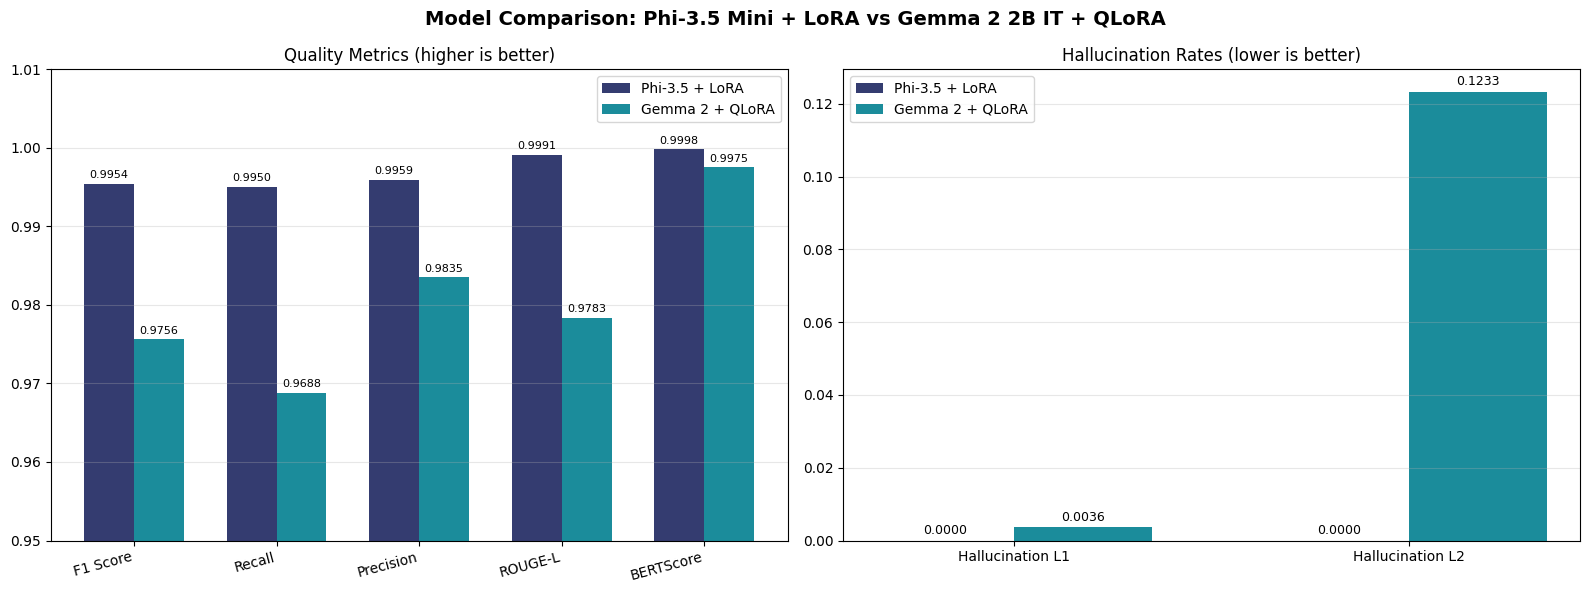

Bar chart saved


In [7]:
# Step 5 - Bar Chart Comparison

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Comparison: Phi-3.5 Mini + LoRA vs Gemma 2 2B IT + QLoRA',
             fontsize=14, fontweight='bold')

# Quality metrics
quality_keys   = ['f1', 'recall', 'precision', 'rouge_l', 'bert_score']
quality_labels = ['F1 Score', 'Recall', 'Precision', 'ROUGE-L', 'BERTScore']
phi35_vals     = [metrics['Phi-3.5 Mini + LoRA'][k]   for k in quality_keys]
gemma2_vals    = [metrics['Gemma 2 2B IT + QLoRA'][k] for k in quality_keys]

x     = np.arange(len(quality_labels))
width = 0.35

bars1 = axes[0].bar(x - width/2, phi35_vals,  width, label='Phi-3.5 + LoRA',  color='#1e2761', alpha=0.9)
bars2 = axes[0].bar(x + width/2, gemma2_vals, width, label='Gemma 2 + QLoRA', color='#028090', alpha=0.9)

axes[0].set_title('Quality Metrics (higher is better)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(quality_labels, rotation=15, ha='right')
axes[0].set_ylim(0.95, 1.01)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
                f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
                f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)

# Hallucination
hall_labels = ['Hallucination L1', 'Hallucination L2']
phi35_hall  = [metrics['Phi-3.5 Mini + LoRA']['hallucination_l1'],   metrics['Phi-3.5 Mini + LoRA']['hallucination_l2']]
gemma2_hall = [metrics['Gemma 2 2B IT + QLoRA']['hallucination_l1'], metrics['Gemma 2 2B IT + QLoRA']['hallucination_l2']]

x2    = np.arange(len(hall_labels))
bars3 = axes[1].bar(x2 - width/2, phi35_hall,  width, label='Phi-3.5 + LoRA',  color='#1e2761', alpha=0.9)
bars4 = axes[1].bar(x2 + width/2, gemma2_hall, width, label='Gemma 2 + QLoRA', color='#028090', alpha=0.9)

axes[1].set_title('Hallucination Rates (lower is better)')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(hall_labels)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

for bar in bars3:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars4:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(output_path + '/bar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Bar chart saved")

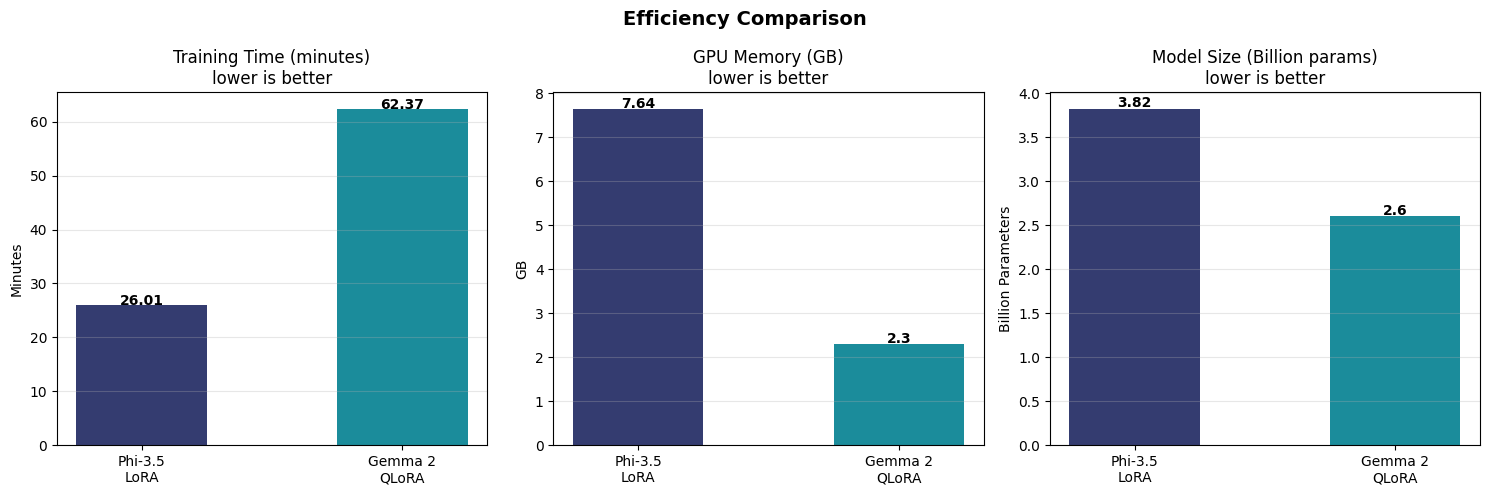

Efficiency chart saved


In [9]:
# Step 6 - Efficiency Comparison

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Efficiency Comparison', fontsize=14, fontweight='bold')

models = ['Phi-3.5\nLoRA', 'Gemma 2\nQLoRA']
colors = ['#1e2761', '#028090']

times  = [26.01, 62.37]
memory = [7.64, 2.3]
sizes  = [3.82, 2.6]

for ax, vals, title, ylabel in zip(
    axes,
    [times, memory, sizes],
    ['Training Time (minutes)\nlower is better', 'GPU Memory (GB)\nlower is better', 'Model Size (Billion params)\nlower is better'],
    ['Minutes', 'GB', 'Billion Parameters']
):
    bars = ax.bar(models, vals, color=colors, alpha=0.9, width=0.5)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(output_path + '/efficiency_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Efficiency chart saved")

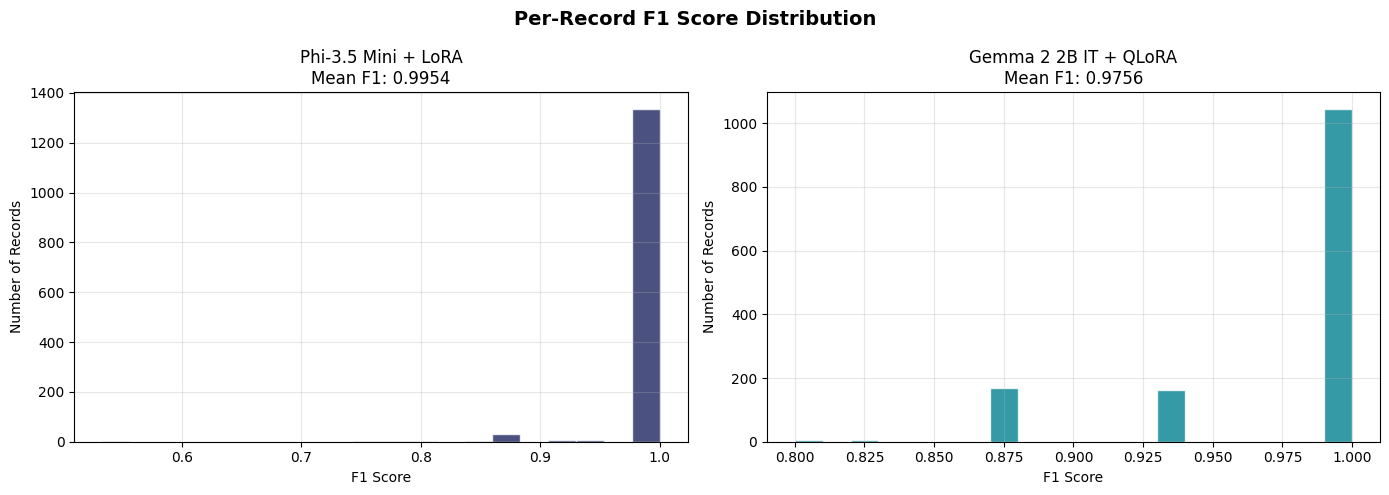

F1 distribution chart saved


In [10]:
# Step 7 - F1 Distribution Per Record

import matplotlib.pyplot as plt
import pandas as pd

df_pred_phi35  = pd.read_csv(pred_paths['Phi-3.5 Mini + LoRA'])
df_pred_gemma2 = pd.read_csv(pred_paths['Gemma 2 2B IT + QLoRA'])

phi35_f1_col  = 'f1' if 'f1' in df_pred_phi35.columns  else 'f1_score'
gemma2_f1_col = 'f1' if 'f1' in df_pred_gemma2.columns else 'f1_score'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Per-Record F1 Score Distribution', fontsize=14, fontweight='bold')

axes[0].hist(df_pred_phi35[phi35_f1_col],  bins=20, color='#1e2761', alpha=0.8, edgecolor='white')
axes[0].set_title(f'Phi-3.5 Mini + LoRA\nMean F1: {df_pred_phi35[phi35_f1_col].mean():.4f}')
axes[0].set_xlabel('F1 Score')
axes[0].set_ylabel('Number of Records')
axes[0].grid(True, alpha=0.3)

axes[1].hist(df_pred_gemma2[gemma2_f1_col], bins=20, color='#028090', alpha=0.8, edgecolor='white')
axes[1].set_title(f'Gemma 2 2B IT + QLoRA\nMean F1: {df_pred_gemma2[gemma2_f1_col].mean():.4f}')
axes[1].set_xlabel('F1 Score')
axes[1].set_ylabel('Number of Records')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_path + '/f1_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("F1 distribution chart saved")